In [29]:
import pandas as pd
import re
from itables import show

data_raw = pd.read_parquet("data.parquet")
print(data_raw.shape)
print(data_raw.iloc[100])
show(data_raw.iloc[100])

(2643425, 70)
material_id                                                          1__2
components                                        methane, carbon dioxide
thermoml_fair_version                                              1.0.25
property                                      Thermal conductivity, W/m/K
value                                                             0.02197
                                                         ...             
Lower temperature, K                                                  NaN
Upper temperature, K                                                  NaN
Amount concentration (molarity), mol/dm3_3                            NaN
Volume ratio of solute to solvent                                     NaN
formula                                                                  
Name: 100, Length: 70, dtype: object


Loading ITables v2.7.0 from the internet... (need help?)


In [1]:
import pandas as pd
import re
from itables import show

data = pd.read_parquet("data.parquet")

# define the regex pattern FIRST
pattern = re.compile(r"(vle|vapor|vapour|equilibr|bubble|dew|p-?x-?y|t-?x-?y|activity|gamma)", re.I)

# find the property column (it might not be exactly 'property')
data_prop_col = next((c for c in data.columns if c.lower() in ["property", "property_id", "prop", "propertyname"]), None)
if data_prop_col is None:
    print("Columns are:", list(data.columns))
    raise ValueError("Couldn't find a property-like column. Pick the correct one from the printed list.")

vle_mask = data[data_prop_col].astype(str).str.contains(pattern, na=False)

# Optional: also require phase info mentioning vapor/liquid if present
phase_col = next((c for c in data.columns if c.lower() in ["phase", "phasename"]), None)
if phase_col is not None:
    vle_mask &= data[phase_col].astype(str).str.contains(r"(vapor|vapour|liquid)", case=False, na=False)

vle = data[vle_mask].copy()
print("VLE-ish rows:", vle.shape)
vle.head()

print(data.shape)

C:\Users\harry\AppData\Local\Temp\ipykernel_31720\3775793239.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  vle_mask = data[data_prop_col].astype(str).str.contains(pattern, na=False)
C:\Users\harry\AppData\Local\Temp\ipykernel_31720\3775793239.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  vle_mask &= data[phase_col].astype(str).str.contains(r"(vapor|vapour|liquid)", case=False, na=False)


VLE-ish rows: (234168, 70)
(2643425, 70)


In [2]:
data.isnull().sum()

material_id                                         0
components                                          0
thermoml_fair_version                               0
property                                            0
value                                               0
                                               ...   
Lower temperature, K                          2643291
Upper temperature, K                          2643291
Amount concentration (molarity), mol/dm3_3    2639130
Volume ratio of solute to solvent             2643395
formula                                             0
Length: 70, dtype: int64

In [ ]:
print(data.iloc[1])
show(data.iloc[1])

material_id                                                             1
components                                                 1,2-ethanediol
thermoml_fair_version                                              1.0.25
property                                      Thermal conductivity, W/m/K
value                                                              0.2518
                                                         ...             
Lower temperature, K                                                  NaN
Upper temperature, K                                                  NaN
Amount concentration (molarity), mol/dm3_3                            NaN
Volume ratio of solute to solvent                                     NaN
formula                                                            C2H6O2
Name: 1, Length: 70, dtype: object


Loading ITables v2.7.0 from the internet... (need help?)


Rows with EXACT binary {water, ethanol}: (5121, 70)
Top properties:
 property
Mass density, kg/m3                                         2895
Viscosity, Pa*s                                              534
Mole fraction                                                447
Boiling temperature at pressure P, K                         296
Refractive index (Na D-line)                                 219
Speed of sound, m/s                                          215
Vapor or sublimation pressure, kPa                           163
Excess molar enthalpy (molar enthalpy of mixing), kJ/mol     144
Thermal conductivity, W/m/K                                  131
Activity coefficient                                          23
Name: count, dtype: int64
Top phases:
 phase
Liquid                                         4428
Gas                                             415
Fluid (supercritical or subcritical phases)     278
Name: count, dtype: int64
Mole-fraction rows for water–ethanol: (152, 7

C:\Users\harry\AppData\Local\Temp\ipykernel_31720\1898959527.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_liq = phase_s.str.contains(r"(liq|liquid|\bl\b)", flags=re.I, na=False)
C:\Users\harry\AppData\Local\Temp\ipykernel_31720\1898959527.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_vap = phase_s.str.contains(r"(vap|vapor|vapour|gas|\bg\b|\bv\b)", flags=re.I, na=False)


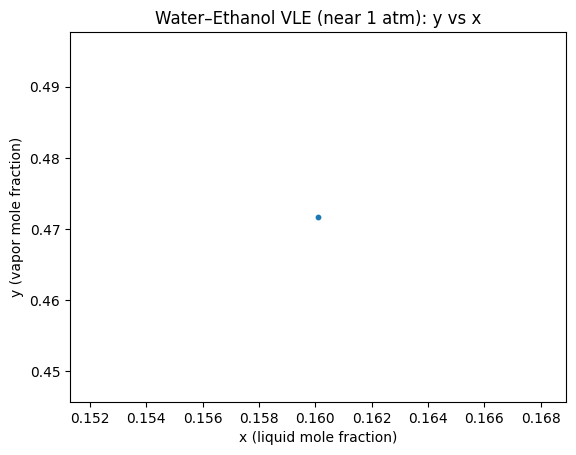

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

data = pd.read_parquet("data.parquet")

# --- 1) Exact component matching (avoid "diethanolamine" trap) ---
# Turn "water, ethanol" into ["water","ethanol"] and match exactly
comps = data["components"].astype(str).str.lower().str.split(r"\s*,\s*")

mask_water_ethanol_binary = comps.apply(lambda xs: set(xs) == {"water", "ethanol"})
df = data[mask_water_ethanol_binary].copy()

print("Rows with EXACT binary {water, ethanol}:", df.shape)
print("Top properties:\n", df["property"].value_counts().head(10))
print("Top phases:\n", df["phase"].value_counts(dropna=False).head(10))

# --- 2) Keep only composition rows stored in property/value ---
mf = df[df["property"].astype(str).str.strip().str.lower().eq("mole fraction")].copy()
mf = mf.dropna(subset=["value", "Temperature, K", "Pressure, kPa", "phase"])
mf = mf[mf["value"].between(0, 1)]

print("Mole-fraction rows for water–ethanol:", mf.shape)
print("Phase counts in mole-fraction rows:\n", mf["phase"].value_counts(dropna=False).head(20))

# --- 3) Normalize phase labels into Liquid vs Vapor/Gas ---
phase_s = mf["phase"].astype(str)
is_liq = phase_s.str.contains(r"(liq|liquid|\bl\b)", flags=re.I, na=False)
is_vap = phase_s.str.contains(r"(vap|vapor|vapour|gas|\bg\b|\bv\b)", flags=re.I, na=False)

mf = mf[is_liq | is_vap].copy()
mf["phase_norm"] = np.where(is_liq.loc[mf.index], "L", "V")

print("After phase filter:", mf.shape)
print(mf["phase_norm"].value_counts())

# --- 4) Pair x (liquid) and y (vapor) at same conditions ---
keys = ["material_id", "doi", "source_file", "Temperature, K", "Pressure, kPa"]

# If multiple rows exist per key/phase, average them (robust)
xy = (
    mf.groupby(keys + ["phase_norm"])["value"]
      .mean()
      .unstack("phase_norm")
      .rename(columns={"L": "x", "V": "y"})
      .dropna(subset=["x", "y"])
      .reset_index()
)

print("Paired x–y points:", xy.shape)

# --- 5) Plot y vs x near 1 atm (optional filter) ---
xy_1atm = xy[(xy["Pressure, kPa"] > 80) & (xy["Pressure, kPa"] < 130)].copy()
print("Paired points near 1 atm:", xy_1atm.shape)

xy_1atm = xy_1atm.sort_values("x")

plt.figure()
plt.scatter(xy_1atm["x"], xy_1atm["y"], s=10)
plt.xlabel("x (liquid mole fraction)")
plt.ylabel("y (vapor mole fraction)")
plt.title("Water–Ethanol VLE (near 1 atm): y vs x")
plt.show()


In [5]:
import pandas as pd
import numpy as np
import re

data = pd.read_parquet("data.parquet")

# --- 1) Exact component matching (avoid "diethanolamine" trap) ---
comps = data["components"].astype(str).str.lower().str.split(r"\s*,\s*")
mask_water_ethanol_binary = comps.apply(lambda xs: set(xs) == {"water", "ethanol"})
df = data[mask_water_ethanol_binary].copy()

# --- 2) Keep only composition rows stored in property/value ---
mf = df[df["property"].astype(str).str.strip().str.lower().eq("mole fraction")].copy()
mf = mf.dropna(subset=["value", "Temperature, K", "Pressure, kPa", "phase"])
mf = mf[mf["value"].between(0, 1)]

# --- 3) Normalize phase labels into Liquid vs Vapor/Gas ---
phase_s = mf["phase"].astype(str)
is_liq = phase_s.str.contains(r"(liq|liquid|\bl\b)", flags=re.I, na=False)
is_vap = phase_s.str.contains(r"(vap|vapor|vapour|gas|\bg\b|\bv\b)", flags=re.I, na=False)

mf = mf[is_liq | is_vap].copy()
mf["phase_norm"] = np.where(is_liq.loc[mf.index], "L", "V")

# --- 4) Pair x (liquid) and y (vapor) at same conditions ---
keys = ["material_id", "doi", "source_file", "Temperature, K", "Pressure, kPa"]

xy = (
    mf.groupby(keys + ["phase_norm"])["value"]
      .mean()
      .unstack("phase_norm")
      .rename(columns={"L": "x", "V": "y"})
      .dropna(subset=["x", "y"])
      .reset_index()
)

# --- 5) Tabular outputs instead of plots ---

# Table 1: File-level summary (how much data per file)
file_summary = (
    df.groupby("source_file")
      .agg(
          rows_total=("property", "size"),
          rows_mole_fraction=("property", lambda s: (s.astype(str).str.strip().str.lower() == "mole fraction").sum()),
          paired_xy_points=("source_file", lambda _: 0),  # placeholder, fill below
          T_min=("Temperature, K", "min"),
          T_max=("Temperature, K", "max"),
          P_min=("Pressure, kPa", "min"),
          P_max=("Pressure, kPa", "max"),
      )
      .reset_index()
)

# fill paired counts per file from xy
paired_counts = xy.groupby("source_file").size().rename("paired_xy_points").reset_index()
file_summary = file_summary.drop(columns=["paired_xy_points"]).merge(paired_counts, on="source_file", how="left")
file_summary["paired_xy_points"] = file_summary["paired_xy_points"].fillna(0).astype(int)
file_summary = file_summary.sort_values(["paired_xy_points", "rows_total"], ascending=False)

print("\n=== Table 1: File summary ===")
print(file_summary.to_string(index=False))

# Table 2: “Diagrams” near 1 atm (group by file + binned pressure)
xy_1atm = xy[(xy["Pressure, kPa"] > 80) & (xy["Pressure, kPa"] < 130)].copy()
xy_1atm["P_bin"] = (xy_1atm["Pressure, kPa"] / 5).round() * 5  # 5 kPa bins
xy_1atm["T_round"] = xy_1atm["Temperature, K"].round(2)

diagram_summary_1atm = (
    xy_1atm.groupby(["source_file", "P_bin"])
          .agg(
              n_points=("x", "size"),
              T_min=("T_round", "min"),
              T_max=("T_round", "max"),
              x_min=("x", "min"),
              x_max=("x", "max"),
              y_min=("y", "min"),
              y_max=("y", "max"),
          )
          .reset_index()
          .sort_values(["n_points"], ascending=False)
)

print("\n=== Table 2: Near-1atm diagram summary (source_file + P_bin) ===")
print(diagram_summary_1atm.to_string(index=False))

# Table 3: Paired points table near 1 atm
xy_1atm_table = xy_1atm.sort_values(["source_file", "P_bin", "T_round", "x"]).reset_index(drop=True)

print("\n=== Table 3: Paired x–y points near 1 atm ===")
print(xy_1atm_table.to_string(index=False))

# (optional) save tables
file_summary.to_csv("water_ethanol_file_summary.csv", index=False)
diagram_summary_1atm.to_csv("water_ethanol_diagram_summary_1atm.csv", index=False)
xy_1atm_table.to_csv("water_ethanol_xy_points_1atm.csv", index=False)

print("\nSaved CSVs:")
print(" - water_ethanol_file_summary.csv")
print(" - water_ethanol_diagram_summary_1atm.csv")
print(" - water_ethanol_xy_points_1atm.csv")



=== Table 1: File summary ===
                                                           source_file  rows_total  rows_mole_fraction  T_min  T_max     P_min     P_max  paired_xy_points
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2012.12.014.xml         152                 152 363.30 423.70   125.700   987.900                74
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2004.11.019.xml         810                   0 298.15 348.15   100.000 40000.000                 0
  C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2004.07.019.xml         565                   0 298.15 573.15   390.000 30300.000                 0
  C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2018.02.022.xml         496                   0 293.15 308.15       NaN       NaN                 0
  C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2006.08.002.xml         326                   0 456.86 673.15  4750.000 50760.000                 0
          C:\Users\harry\.thermoml\extr

C:\Users\harry\AppData\Local\Temp\ipykernel_31720\1804404246.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_liq = phase_s.str.contains(r"(liq|liquid|\bl\b)", flags=re.I, na=False)
C:\Users\harry\AppData\Local\Temp\ipykernel_31720\1804404246.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_vap = phase_s.str.contains(r"(vap|vapor|vapour|gas|\bg\b|\bv\b)", flags=re.I, na=False)


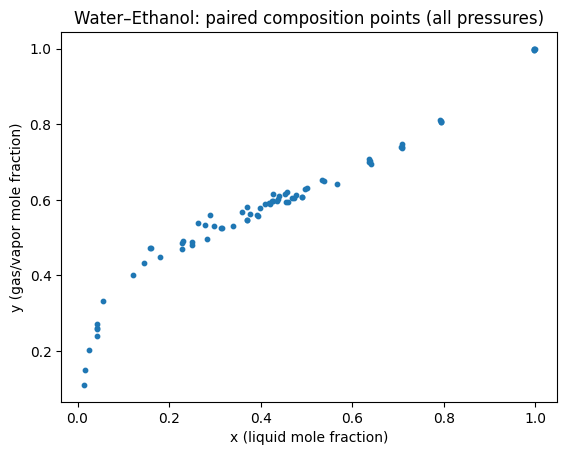

In [6]:
import matplotlib.pyplot as plt

xy_all = xy.sort_values("x")

plt.figure()
plt.scatter(xy_all["x"], xy_all["y"], s=10)
plt.xlabel("x (liquid mole fraction)")
plt.ylabel("y (gas/vapor mole fraction)")
plt.title("Water–Ethanol: paired composition points (all pressures)")
plt.show()

In [7]:
for i, data_dir in enumerate(df["source_file"].value_counts().head(10).index):
    df_sf = df[df["source_file"] == data_dir].copy()
    df_sf.to_csv(f"water_ethanol_raw_rows_one_source_file{i}.csv", index=False)

    print("Saved rows:", len(df_sf), "from source_file:", data_dir)

Saved rows: 810 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2004.11.019.xml
Saved rows: 565 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2004.07.019.xml
Saved rows: 496 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2018.02.022.xml
Saved rows: 326 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2006.08.002.xml
Saved rows: 216 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1021\je800150h.xml
Saved rows: 168 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2015.07.012.xml
Saved rows: 164 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1021\je060335h.xml
Saved rows: 164 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1021\je900266h.xml
Saved rows: 152 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2012.12.014.xml
Saved rows: 144 from source_file: C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.20

In [8]:
mix_counts = data["components"].astype(str).str.lower().value_counts()
print(mix_counts.head(50))

components
germanium iron lithium oxide (ge2felio6), germanium iron sodium oxide (ge2fenao6)    15941
decane                                                                               10684
pentaerythritol tetrahexanoate                                                       10246
pentaerythritol tetraheptanoate                                                       7686
ammonium nitrate, water, calcium nitrate                                              7444
1,1,1,2,3,3,3-heptafluoropropane                                                      7428
water                                                                                 6530
pentaerythritol tetrapentanoate                                                       5403
ethanol, water                                                                        5038
pentaerythritol tetrabutyrate                                                         4770
pentaerythritol tetraoctanoate                                                 

In [9]:
tmp = data.copy()
tmp["comp_list"] = tmp["components"].astype(str).str.lower().str.split(r"\s*,\s*")
tmp["ncomp"] = tmp["comp_list"].apply(lambda xs: len(set(xs)))
tmp["mix_key"] = tmp["comp_list"].apply(lambda xs: "|".join(sorted(set(xs))))

binary = tmp[tmp["ncomp"] == 2]

summary = (
    binary.groupby("mix_key")["source_file"].nunique()
          .sort_values(ascending=False)
)

print("Number of unique binary mixtures:", summary.shape[0])
print(summary.head(30))          # top 30 by #files


Number of unique binary mixtures: 20372
mix_key
sodium chloride|water                                  121
1|2-ethanediol                                         112
1|4-dimethylbenzene                                    107
1|2-dimethylbenzene                                     93
1|3-dimethylbenzene                                     86
potassium chloride|water                                86
2|4-trimethylpentane                                    80
2-aminoacetic acid|water                                79
n|n-dimethylethanamide                                  73
ethanol|water                                           72
1|4-dioxane                                             65
carbon dioxide|water                                    53
1|2-propanediol                                         51
(s)-2-aminopropanoic acid|water                         51
1|2-dichloroethane                                      50
1|2-tetrafluoroethane                                   48
d-glucos

In [10]:
import re
import pandas as pd

# Split only on commas that are NOT between digits (keeps 1,2-ethanediol intact)
SPLIT_COMPONENTS = re.compile(r"(?<!\d)\s*,\s*(?!\d)")

def parse_components(s: str):
    s = "" if pd.isna(s) else str(s).strip().lower()
    parts = [p.strip() for p in SPLIT_COMPONENTS.split(s) if p.strip()]
    # de-duplicate while preserving order
    seen = set()
    out = []
    for p in parts:
        if p not in seen:
            out.append(p)
            seen.add(p)
    return out

tmp = data.copy()
tmp["comp_list_fixed"] = tmp["components"].apply(parse_components)
tmp["ncomp_fixed"] = tmp["comp_list_fixed"].apply(len)
tmp["mix_key_fixed"] = tmp["comp_list_fixed"].apply(lambda xs: "|".join(sorted(xs)))

# True binaries = exactly 2 components after the fixed parsing
true_binary = tmp[tmp["ncomp_fixed"] == 2].copy()

print("True binary mixtures (fixed parsing):", true_binary["mix_key_fixed"].nunique())
print(true_binary["mix_key_fixed"].value_counts().head(20))
# Your old method (naive) for comparison:
tmp["comp_list_old"] = tmp["components"].astype(str).str.lower().str.split(r"\s*,\s*")
tmp["ncomp_old"] = tmp["comp_list_old"].apply(lambda xs: len(set([x.strip() for x in xs if str(x).strip()])))

# Fake binaries: old says 2, fixed says 1 (usually locant comma issue)
fake_binary = tmp[(tmp["ncomp_old"] == 2) & (tmp["ncomp_fixed"] == 1)].copy()

print("Fake binaries (old==2 but fixed==1):", fake_binary.shape[0])
print(fake_binary["components"].head(30).to_string(index=False))
old_binary = tmp[tmp["ncomp_old"] == 2].copy()
old_binary["mix_key_old"] = old_binary["comp_list_old"].apply(lambda xs: "|".join(sorted(set([x.strip() for x in xs if str(x).strip()]))))

print("Old top binaries:")
print(old_binary["mix_key_old"].value_counts().head(10))

print("\nFixed top binaries:")
print(true_binary["mix_key_fixed"].value_counts().head(10))


True binary mixtures (fixed parsing): 27331
mix_key_fixed
germanium iron lithium oxide (ge2felio6)|germanium iron sodium oxide (ge2fenao6)    15941
ethanol|water                                                                        5121
carbon dioxide|methanol                                                              4546
triethylene glycol|water                                                             3638
methanol|water                                                                       3617
difluoromethane|pentafluoroethane                                                    3195
carbon dioxide|water                                                                 3081
2-aminoacetic acid|water                                                             3019
propan-2-ol|water                                                                    2967
propan-1-ol|water                                                                    2789
diisopropyl ether|propan-2-ol             

In [11]:
print("\nFixed top binaries:")
print(true_binary["mix_key_fixed"].value_counts())


Fixed top binaries:
mix_key_fixed
germanium iron lithium oxide (ge2felio6)|germanium iron sodium oxide (ge2fenao6)    15941
ethanol|water                                                                        5121
carbon dioxide|methanol                                                              4546
triethylene glycol|water                                                             3638
methanol|water                                                                       3617
                                                                                    ...  
5-ethyl-2-methyl-1-octylpyridinium dicyanamide|water                                    1
3,5-dimethyl-1-octylpyridinium thiocyanate|water                                        1
2,3-dimethyl-1-octylpyridinium thiocyanate|water                                        1
3-phenyl-1-propanol|water                                                               1
4-phenyl-1-butanol|water                                         

In [12]:
# true_binary: tmp[tmp["ncomp_fixed"] == 2] from the fixed parsing step

rows_per_file = true_binary.groupby("source_file").size().sort_values()

min_rows = int(rows_per_file.min())
print("Minimum #rows in a file (among fixed binaries):", min_rows)

print("\nFile(s) with that minimum:")
print("\n".join(rows_per_file[rows_per_file == min_rows].index.tolist()))

# (optional) show all files with their row counts
print("\nSmallest 20 files by #rows:")
print(rows_per_file)

Minimum #rows in a file (among fixed binaries): 1

File(s) with that minimum:
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.tca.2005.11.035.xml
C:\Users\harry\.thermoml\extracted_xml\10.1021\je0502492.xml
C:\Users\harry\.thermoml\extracted_xml\10.1021\je400487e.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2014.11.002.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2013.11.024.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2013.09.030.xml
C:\Users\harry\.thermoml\extracted_xml\10.1021\acs.jced.6b00954.xml
C:\Users\harry\.thermoml\extracted_xml\10.1021\acs.jced.7b00505.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2013.04.007.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2013.03.009.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2013.02.011.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2013.06.004.xml
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2007.07.070.xml
C:\Users\harry\.thermoml\extracted_xml\

In [13]:
MIN_ROWS = 5

rows_per_file = true_binary.groupby("source_file").size()
keep_files = rows_per_file[rows_per_file >= MIN_ROWS].index

true_binary_5plus = true_binary[true_binary["source_file"].isin(keep_files)].copy()

print("Files before:", rows_per_file.size)
print("Files after :", len(keep_files))
print("Rows before :", len(true_binary))
print("Rows after  :", len(true_binary_5plus))


Files before: 8106
Files after : 7780
Rows before : 1337241
Rows after  : 1336386


In [14]:
dropped = rows_per_file[rows_per_file < MIN_ROWS].sort_values()
print("Dropped files:", len(dropped))
print(dropped.head(30))

Dropped files: 326
source_file
C:\Users\harry\.thermoml\extracted_xml\10.1007\s10765-011-0987-x.xml      1
C:\Users\harry\.thermoml\extracted_xml\10.1021\je900936t.xml              1
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2013.11.024.xml    1
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2014.12.047.xml    1
C:\Users\harry\.thermoml\extracted_xml\10.1021\je301267r.xml              1
C:\Users\harry\.thermoml\extracted_xml\10.1021\je400487e.xml              1
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2016.05.009.xml    1
C:\Users\harry\.thermoml\extracted_xml\10.1021\je0603628.xml              1
C:\Users\harry\.thermoml\extracted_xml\10.1021\je0502492.xml              1
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.fluid.2017.09.023.xml    1
C:\Users\harry\.thermoml\extracted_xml\10.1021\je049586l.xml              1
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2006.03.003.xml      1
C:\Users\harry\.thermoml\extracted_xml\10.1016\j.jct.2004

In [15]:
# true_binary_5plus from the previous step
binaries = (
    true_binary_5plus["mix_key_fixed"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Number of unique binaries kept:", len(binaries))
print("\n".join(binaries))


Number of unique binaries kept: 27178
((benzyloxy)carbonyl)-l-phenylalanine|carbon dioxide
((oxybis(ethane-2,1-diyl))bis(oxy))bis(ethane-2,1-diyl) bis(2-methylacrylate)|carbon dioxide
((s)-1-ethoxy-1-oxo-4-phenylbutan-2-yl)-l-alanine|acetone
((s)-1-ethoxy-1-oxo-4-phenylbutan-2-yl)-l-alanine|acetonitrile
((s)-1-ethoxy-1-oxo-4-phenylbutan-2-yl)-l-alanine|ethanol
((s)-1-ethoxy-1-oxo-4-phenylbutan-2-yl)-l-alanine|ethyl acetate
((s)-1-ethoxy-1-oxo-4-phenylbutan-2-yl)-l-alanine|octan-1-ol
((s)-1-ethoxy-1-oxo-4-phenylbutan-2-yl)-l-alanine|propan-2-ol
(+)-.alpha.-tocopherol|carbon dioxide
(+)-3-carene|2-pinene
(+)-camphorquinone|ethanol
(+)-catechin|water
(+)-fenchone|benzene
(+)-fenchone|cyclohexane
(+)-fenchone|ethanol
(+)-fenchone|tetrachloromethane
(+)-galactose|1-ethyl-3-methylimidazolium ethyl sulfate
(+)-galactose|1-ethyl-3-methylimidazolium thiocyanate
(+)-galactose|ethanol
(+)-galactose|tris(2-hydroxyethyl) methylammonium methylsulfate
(+)-galactose|water
(+)-simvastatin|1,1-dimethyle

In [16]:
binary_file_counts = (
    true_binary_5plus.groupby("mix_key_fixed")["source_file"]
    .nunique()
    .sort_values(ascending=False)
)

print(binary_file_counts)  # top 50

mix_key_fixed
sodium chloride|water                                             113
potassium chloride|water                                           78
2-aminoacetic acid|water                                           73
ethanol|water                                                      70
n|n-dimethylethanamide                                             61
                                                                 ... 
(+)-simvastatin|1,1-dimethylethyl ethanoate                         1
(+)-simvastatin|1-methylethyl ethanoate                             1
(+)-simvastatin|1-methylpropyl ethanoate                            1
1,2-propanediol|tetrabutylammonium bromide                          1
((s)-1-ethoxy-1-oxo-4-phenylbutan-2-yl)-l-alanine|acetonitrile      1
Name: source_file, Length: 27178, dtype: int64


In [17]:
binary_row_counts = true_binary_5plus["mix_key_fixed"].value_counts()
print(binary_row_counts)

mix_key_fixed
germanium iron lithium oxide (ge2felio6)|germanium iron sodium oxide (ge2fenao6)    15941
ethanol|water                                                                        5116
carbon dioxide|methanol                                                              4546
triethylene glycol|water                                                             3635
methanol|water                                                                       3617
                                                                                    ...  
2,3,5-trimethyl-1-octylpyridinium 1,1,1-trifluoromethanesulfonate|water                 1
3,5-dimethyl-1-octylpyridinium dicyanamide|water                                        1
5-ethyl-2-methyl-1-octylpyridinium dicyanamide|water                                    1
3,5-dimethyl-1-octylpyridinium thiocyanate|water                                        1
2,3-dimethyl-1-octylpyridinium thiocyanate|water                                      

In [18]:
new_binary_row_counts = binary_row_counts[binary_row_counts > 50]
print(new_binary_row_counts)
print(sum(new_binary_row_counts))

mix_key_fixed
germanium iron lithium oxide (ge2felio6)|germanium iron sodium oxide (ge2fenao6)    15941
ethanol|water                                                                        5116
carbon dioxide|methanol                                                              4546
triethylene glycol|water                                                             3635
methanol|water                                                                       3617
                                                                                    ...  
1-undecanol|acetonitrile                                                               51
cyclohexylamine|toluene                                                                51
2-methylbutan-2-ol|ethyl acetate                                                       51
oxygen|toluene                                                                         51
carbon dioxide|pentaerythritol tetrapentanoate                                        

In [19]:
true_binary_5plus_high_row_count = true_binary_5plus[true_binary_5plus['mix_key_fixed'].isin(new_binary_row_counts.index)]
print(f"Filtered shape: {true_binary_5plus_high_row_count.shape}")
print(true_binary_5plus_high_row_count['mix_key_fixed'].value_counts())

Filtered shape: (1099538, 73)
mix_key_fixed
germanium iron lithium oxide (ge2felio6)|germanium iron sodium oxide (ge2fenao6)    15941
ethanol|water                                                                        5116
carbon dioxide|methanol                                                              4546
triethylene glycol|water                                                             3635
methanol|water                                                                       3617
                                                                                    ...  
1-undecanol|acetonitrile                                                               51
cyclohexylamine|toluene                                                                51
2-methylbutan-2-ol|ethyl acetate                                                       51
oxygen|toluene                                                                         51
carbon dioxide|pentaerythritol tetrapentanoate          

In [22]:
true_binary_5plus_high_row_count.iloc[1]

material_id                                                 1__2
components                               methane, carbon dioxide
thermoml_fair_version                                     1.0.25
property                             Thermal conductivity, W/m/K
value                                                    0.02125
                                                ...             
Volume ratio of solute to solvent                            NaN
formula                                                         
comp_list_fixed                        [methane, carbon dioxide]
ncomp_fixed                                                    2
mix_key_fixed                             carbon dioxide|methane
Name: 98, Length: 73, dtype: object

In [21]:
#true_binary_5plus_high_row_count.to_csv("true_binary_5plus_high_row_count.csv", index=False)
#print("CSV saved: true_binary_5plus_high_row_count.csv")

In [23]:
# Split true_binary_5plus_high_row_count in half and save to CSV
n = len(true_binary_5plus_high_row_count)
mid = n // 2

df_half1 = true_binary_5plus_high_row_count.iloc[:mid]
df_half2 = true_binary_5plus_high_row_count.iloc[mid:]

df_half1.to_csv("true_binary_5plus_high_row_count_part1.csv", index=False)
df_half2.to_csv("true_binary_5plus_high_row_count_part2.csv", index=False)

print(f"Total rows: {n}")
print(f"Part 1 rows: {len(df_half1)}")
print(f"Part 2 rows: {len(df_half2)}")
print("Saved:")
print(" - true_binary_5plus_high_row_count_part1.csv")
print(" - true_binary_5plus_high_row_count_part2.csv")

Total rows: 1099538
Part 1 rows: 549769
Part 2 rows: 549769
Saved:
 - true_binary_5plus_high_row_count_part1.csv
 - true_binary_5plus_high_row_count_part2.csv
